**Impact of Gaming Behavior on Academic and Psychological Outcomes**

> Big Data Analysis / Data Science Project by Akhmadjonov Sh



In [129]:
from google.colab import files
uploaded = files.upload()

Saving data_4.csv to data_4 (2).csv


In [130]:
import pandas as pd

df = pd.read_csv("data_4.csv")

In [131]:
from sklearn.preprocessing import OneHotEncoder
my_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform="pandas")

In [132]:
df.head()

,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,Female,8615,3.68,22,17,5.26,1.00,0.18,3,...,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,Female,39453,5.70,34,16,9.20,0.70,1.44,8,...,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,Male,40466,1.58,8,22,7.39,2.24,3.15,3,...,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,Male,51076,6.11,39,24,7.99,1.65,2.80,1,...,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,Male,86116,3.65,17,0,7.12,1.02,1.01,2,...,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1005 non-null   int64  
 1   gender                      1005 non-null   object 
 2   income                      1005 non-null   int64  
 3   daily_gaming_hours          1005 non-null   float64
 4   weekly_sessions             1005 non-null   int64  
 5   years_gaming                1005 non-null   int64  
 6   sleep_hours                 1005 non-null   float64
 7   caffeine_intake             1005 non-null   float64
 8   exercise_hours              1005 non-null   float64
 9   stress_level                1005 non-null   int64  
 10  anxiety_score               1005 non-null   float64
 11  depression_score            1005 non-null   float64
 12  social_interaction_score    1005 non-null   float64
 13  relationship_satisfaction   1005 

In [134]:
df.describe()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,...,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.00000
mean,35.942289,76684.697512,3.944657,19.523383,11.758209,6.992338,2.060537,1.999582,5.416915,4.830438,...,5.109453,4.976090,4.956468,5.999393,24.186219,7.925264,5.045990,3.982995,49.895522,5.60995
std,13.515988,41555.712105,2.877536,11.319372,7.206836,1.482334,2.054700,2.043844,2.865913,1.929894,...,3.157859,1.941267,1.993696,1.931674,3.986858,4.020046,1.972545,1.936471,28.836778,2.88441
min,13.000000,5025.000000,0.070000,1.000000,0.000000,2.940000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,11.070000,0.580000,0.000000,0.000000,0.000000,1.00000
25%,24.000000,40754.000000,1.790000,10.000000,5.000000,5.990000,0.580000,0.540000,3.000000,3.480000,...,2.000000,3.640000,3.620000,4.700000,21.500000,4.950000,3.700000,2.730000,26.000000,3.00000
50%,37.000000,75490.000000,3.290000,20.000000,12.000000,6.980000,1.390000,1.400000,5.000000,4.870000,...,5.000000,4.900000,5.030000,5.990000,24.150000,7.390000,5.070000,3.940000,49.000000,6.00000
75%,47.000000,112442.000000,5.460000,29.000000,18.000000,7.950000,2.870000,2.800000,8.000000,6.080000,...,8.000000,6.230000,6.240000,7.340000,26.800000,10.250000,6.380000,5.270000,75.000000,8.00000
max,59.000000,149698.000000,17.660000,39.000000,24.000000,11.490000,12.080000,15.800000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,37.030000,32.560000,10.000000,10.000000,99.000000,10.00000


In [135]:
df.isna().sum().sum()

np.int64(0)

We do not have any missing values xD

In [136]:
df.duplicated().sum()

np.int64(0)

Let's see how features in our data is correlated to each other.

In [137]:
df["gender"].value_counts()

,count
gender,
Female,487
Male,480
Other,38


Encoding "Gender Feature"

In [138]:
gender_transform = my_encoder.fit_transform(df[['gender']])
gender_transform.head()

,gender_Female,gender_Male,gender_Other
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0


In [139]:
numeric_cols = df.select_dtypes(["number"]) #we stored all featues which are number only, from our data to numeric_cols variable

In [140]:
numeric_cols.corr()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
age,1.000000,-0.000228,-0.020407,-0.016443,0.036637,0.028225,0.016161,-0.025598,0.047240,0.025784,...,0.053774,0.012019,0.011233,-0.023995,-0.029560,-0.023387,0.001064,0.052590,0.015527,-0.020020
income,-0.000228,1.000000,0.052987,-0.023754,0.045455,0.017392,-0.032998,-0.028402,-0.024877,0.029381,...,0.029680,-0.023600,0.019798,-0.000770,0.015048,0.011805,-0.025650,-0.026007,-0.008277,0.049202
daily_gaming_hours,-0.020407,0.052987,1.000000,-0.052907,-0.016637,0.029801,-0.020572,-0.001875,0.016120,-0.011148,...,-0.035111,-0.051607,0.001994,0.039095,-0.043996,0.726846,-0.034936,-0.006680,-0.029179,0.054417
weekly_sessions,-0.016443,-0.023754,-0.052907,1.000000,-0.005236,-0.011382,-0.001359,0.020280,0.057160,0.007615,...,-0.005672,0.006377,-0.016248,0.024151,-0.019500,-0.026478,-0.047271,0.036714,-0.016410,-0.036175
years_gaming,0.036637,0.045455,-0.016637,-0.005236,1.000000,-0.012522,-0.026343,0.002770,-0.054429,0.044887,...,-0.012097,0.027038,0.007743,0.046036,0.001219,-0.032934,-0.010378,0.011515,-0.027612,0.054010
sleep_hours,0.028225,0.017392,0.029801,-0.011382,-0.012522,1.000000,-0.010239,0.002918,0.010717,0.068726,...,0.010559,-0.023220,0.004717,0.017947,-0.033936,0.027413,-0.003346,0.015829,-0.031946,-0.062268
caffeine_intake,0.016161,-0.032998,-0.020572,-0.001359,-0.026343,-0.010239,1.000000,-0.004110,0.011591,-0.007568,...,0.009257,0.035137,0.025412,0.066756,-0.055769,-0.009997,0.010728,0.011365,-0.056663,0.008773
exercise_hours,-0.025598,-0.028402,-0.001875,0.020280,0.002770,0.002918,-0.004110,1.000000,0.037767,-0.014742,...,0.012364,0.007805,-0.029841,-0.000434,-0.063440,0.014865,-0.047990,-0.015808,-0.005365,-0.019871
stress_level,0.047240,-0.024877,0.016120,0.057160,-0.054429,0.010717,0.011591,0.037767,1.000000,0.018132,...,0.005078,-0.010711,-0.016647,0.027558,0.018801,0.022045,-0.013943,-0.006089,-0.081329,-0.020311
anxiety_score,0.025784,0.029381,-0.011148,0.007615,0.044887,0.068726,-0.007568,-0.014742,0.018132,1.000000,...,-0.006135,0.020455,0.003760,-0.053172,-0.076416,-0.013983,-0.033127,-0.042226,-0.031593,0.036959


In [141]:
print(df["addiction_level"].quantile(0.33))
print(df["addiction_level"].quantile(0.66))

1.5832
3.4092


In [142]:
bins = [0, 1.5832, 3.4092, 10]
labels = ["Low", "Medium", "High"]

df["addiction_category"] = pd.cut(df["addiction_level"], bins=bins, labels=labels)

df["addiction_category"].head()

,addiction_category
0,Medium
1,High
2,Low
3,Medium
4,Medium


In [143]:
df["addiction_category"].shape

(1005,)

In [144]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['addiction_category_encoded'] = le.fit_transform(df['addiction_category'])

I split the data into Training and Test before starting the preprocessing

In [145]:
x_reg = df[['age', 'income', 'daily_gaming_hours', 'weekly_sessions', 'years_gaming', 'weekend_gaming_hours', 'sleep_hours', 'caffeine_intake', 'exercise_hours', 'stress_level', 'anxiety_score', 'depression_score', 'social_interaction_score', 'relationship_satisfaction', 'loneliness_score', 'aggression_score', 'happiness_score', 'bmi', 'screen_time_total', 'eye_strain_score', 'back_pain_score', 'streaming_hours', 'microtransactions_spending', 'friends_gaming_count', 'online_friends', 'competitive_rank', 'internet_quality', 'esports_interest', 'parental_supervision', 'addiction_level']]
x_reg = pd.concat([x_reg, gender_transform], axis=1)
y_reg = df['academic_performance']

Splitting for Regression Target

In [146]:
from sklearn.model_selection import train_test_split
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)

print(x_train_reg.shape)
print(y_train_reg.shape)
print(x_test_reg.shape)
print(y_test_reg.shape)

(804, 33)
(804,)
(201, 33)
(201,)


In [147]:
x_train_reg.head()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,weekend_gaming_hours,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,friends_gaming_count,online_friends,competitive_rank,internet_quality,esports_interest,parental_supervision,addiction_level,gender_Female,gender_Male,gender_Other
78,35,92892,4.42,25,23,9.26,8.24,2.59,4.87,4,...,14,217,62,8,0,7,3.26,0.0,1.0,0.0
29,39,141414,1.02,38,5,2.77,5.28,0.48,1.55,9,...,8,383,24,3,7,2,0.80,1.0,0.0,0.0
280,23,74760,0.67,7,20,11.14,5.77,0.91,0.24,2,...,21,93,96,6,2,0,0.23,0.0,1.0,0.0
507,52,38418,1.03,29,23,8.06,5.22,4.87,0.72,3,...,18,408,57,8,5,5,1.38,0.0,0.0,1.0
652,45,56418,1.12,32,19,4.05,10.24,0.17,4.74,6,...,11,121,28,6,1,6,0.86,0.0,1.0,0.0


**Splitting for Classification**

In [148]:
x_clf = df[['age', 'income', 'daily_gaming_hours', 'weekly_sessions', 'years_gaming', 'weekend_gaming_hours', 'sleep_hours', 'caffeine_intake', 'exercise_hours', 'stress_level', 'anxiety_score', 'depression_score', 'social_interaction_score', 'relationship_satisfaction', 'loneliness_score', 'aggression_score', 'happiness_score', 'bmi', 'screen_time_total', 'eye_strain_score', 'back_pain_score', 'streaming_hours', 'microtransactions_spending', 'friends_gaming_count', 'online_friends', 'competitive_rank', 'internet_quality', 'esports_interest', 'parental_supervision', 'academic_performance']]
y_clf = df['addiction_category_encoded']

x_clf = pd.concat([x_clf, gender_transform], axis=1)

In [154]:
x_train_clf, x_test_clf, y_train_clf, y_test_clf = train_test_split(x_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(x_train_clf.shape)
print(y_train_clf.shape)
print(x_test_clf.shape)
print(y_test_clf.shape)

(804, 33)
(804,)
(201, 33)
(201,)


In [155]:
x_train_clf.head()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,weekend_gaming_hours,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,friends_gaming_count,online_friends,competitive_rank,internet_quality,esports_interest,parental_supervision,academic_performance,gender_Female,gender_Male,gender_Other
949,43,67553,1.71,6,14,2.49,4.43,0.29,0.12,10,...,43,470,61,6,2,8,60.95,0.0,1.0,0.0
22,14,35076,1.14,34,5,9.93,6.63,3.42,0.29,10,...,16,330,87,3,8,8,63.14,0.0,1.0,0.0
214,14,66756,5.42,28,17,3.00,7.82,0.67,0.93,5,...,20,229,22,4,2,9,65.54,0.0,0.0,1.0
545,51,40696,1.24,32,6,9.25,7.39,1.13,2.27,8,...,45,211,94,1,9,3,100.00,1.0,0.0,0.0
546,44,147255,3.08,6,19,4.47,5.07,2.76,0.27,8,...,11,193,43,9,8,10,77.16,0.0,1.0,0.0


In [156]:
y_train_clf.head()

,addiction_category_encoded
949,3
22,2
214,0
545,2
546,2


In [157]:
y_test_clf.head()

,addiction_category_encoded
924,0
469,2
53,1
148,1
557,3


In [159]:
print(x_train_reg.shape)
print(y_train_reg.shape)
print(x_test_clf.shape)
print(y_test_clf.shape)

(804, 33)
(804,)
(201, 33)
(201,)


**Data Visualization** - 5 visuals

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

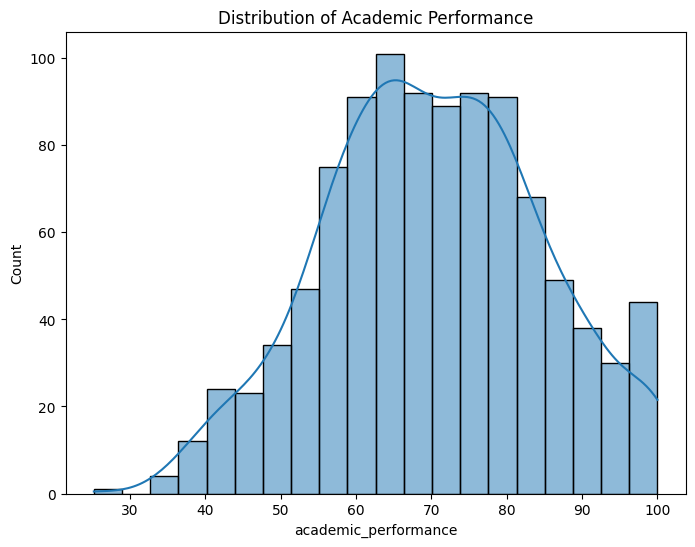

In [168]:
plt.figure(figsize=(8, 6))
sns.histplot(df['academic_performance'], bins=20, kde=True)
plt.title('Distribution of Academic Performance')
plt.show()

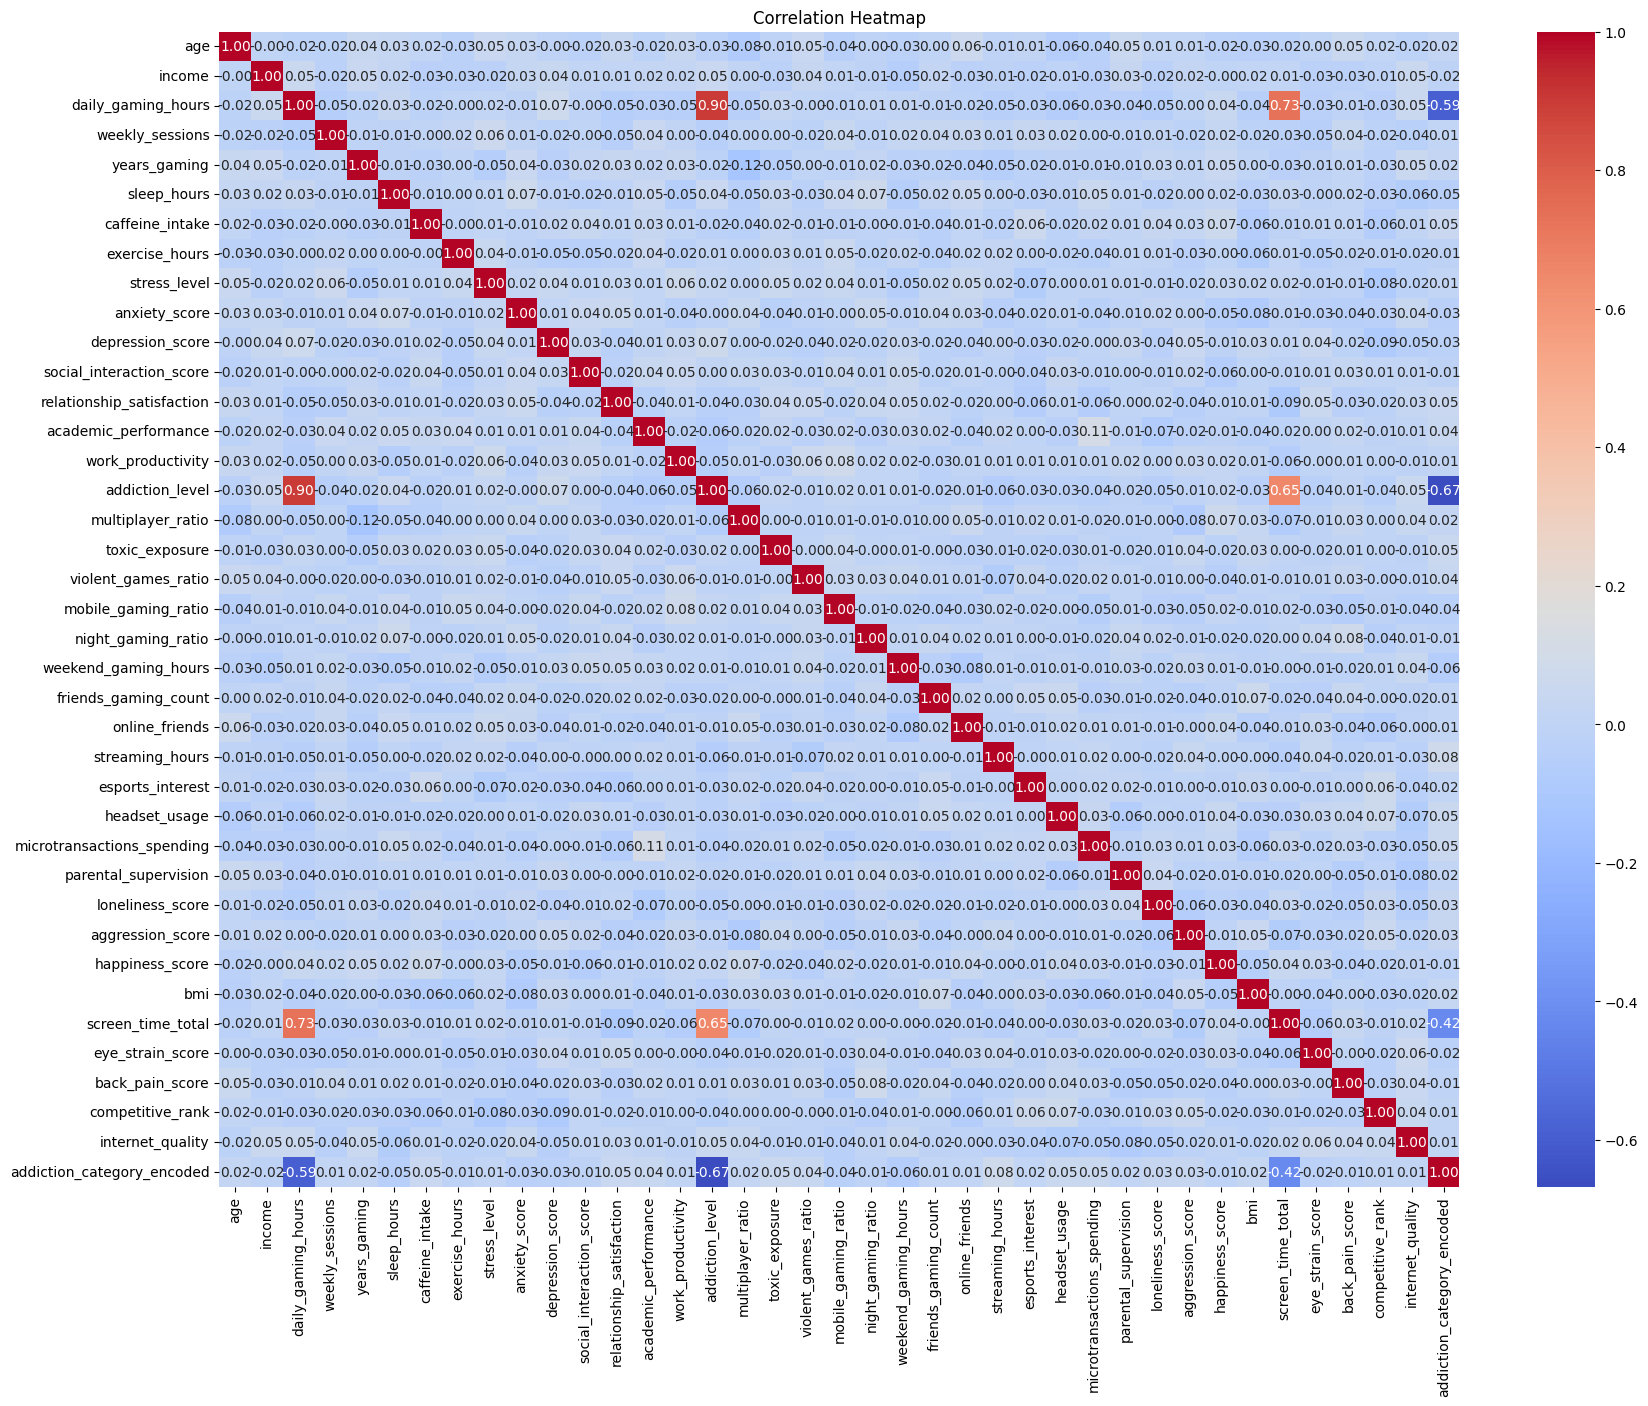

In [176]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

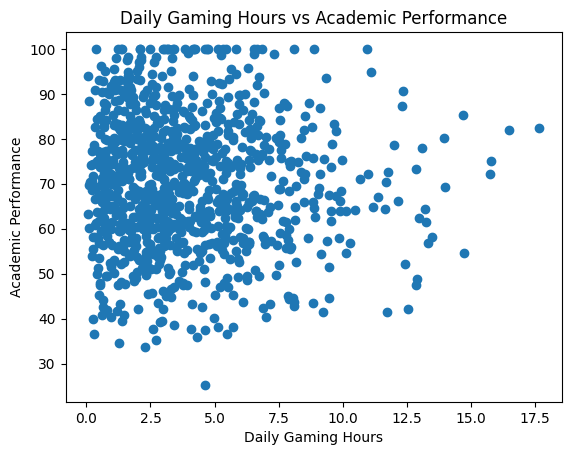

In [178]:
x = df["daily_gaming_hours"]
y = df["academic_performance"]
plt.scatter(x, y)
plt.title("Daily Gaming Hours vs Academic Performance")
plt.xlabel("Daily Gaming Hours")
plt.ylabel("Academic Performance")

plt.show()

Text(0.5, 0.98, 'Academic Performance by Addiction Category')

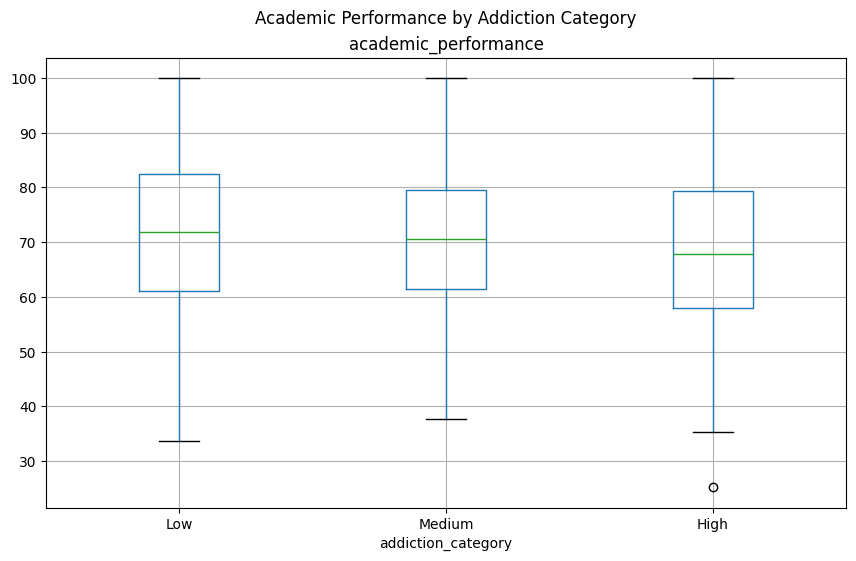

In [186]:
g_boxplot = df.boxplot(column="academic_performance", by="addiction_category", figsize=(10,6))
g_boxplot.set_ylabel = "Academic Performance"
g_boxplot.set_xlabel = "Addiction Category"
plt.suptitle("Academic Performance by Addiction Category")

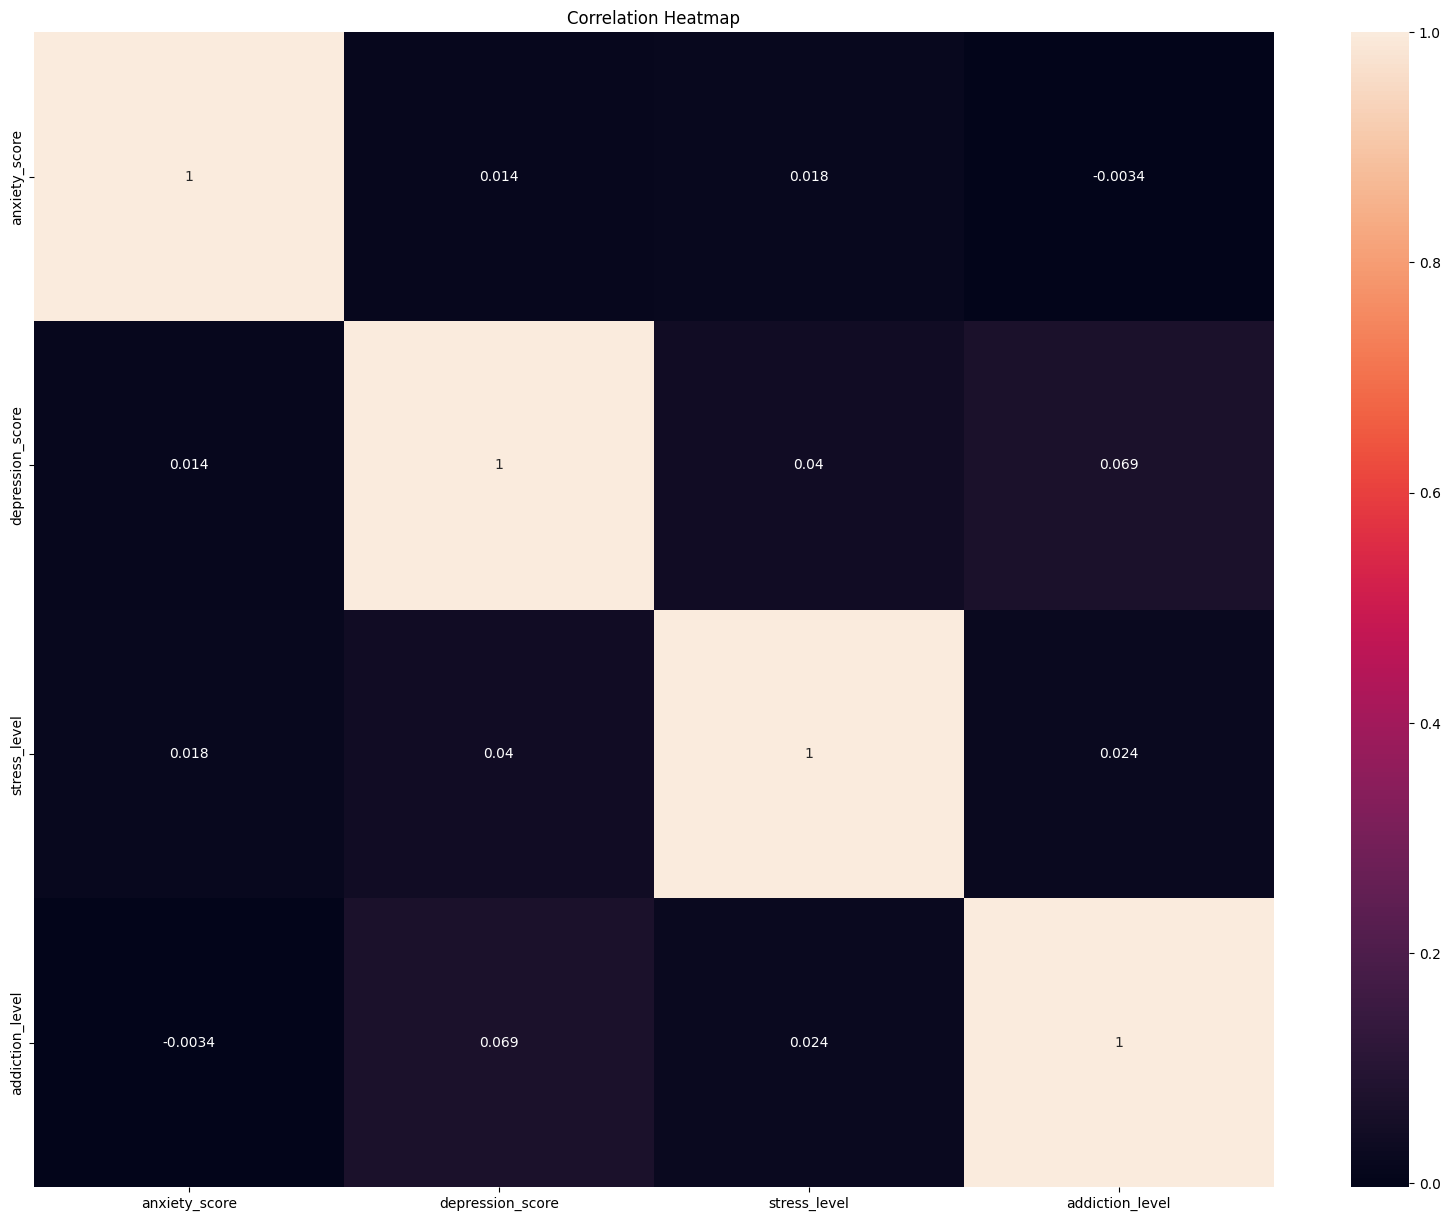

In [194]:
plt.figure(figsize=(20,15))
sns.heatmap(df[["anxiety_score", "depression_score", "stress_level", "addiction_level"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()